# EDA of the IUCN Red List 2024 Data - Direction B: Population Forecasting

**Objective:** Exploratory Data Analysis of the IUCN Red List dataset and assessment of its utility for population forecasting

**Approach:**
1. Dataset Overview & Structure
2. Taxonomic Distribution & Classification
3. IUCN Conservation Status Categories
4. Data Quality Assessment
5. Population Data Availability (Critical for Forecasting)
6. Comparison with WWF LPD Dataset
7. Pro & Cons for Population Forecasting Project
8. Merge Strategy & Recommendations

## Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load both datasets for comparison
df_iucn = pd.read_csv('../data/raw/Kaggle-IUCN.csv')
df_wwf = pd.read_csv('../data/raw/WWF_LPD_2024_public.csv')

print("=" * 80)
print("IUCN RED LIST 2024 - POPULATION FORECASTING EDA & COMPARISON")
print("=" * 80)
print(f"\nIUCN Dataset Shape: {df_iucn.shape}")
print(f"WWF Dataset Shape: {df_wwf.shape}")
print(f"IUCN Records: {df_iucn.shape[0]}")
print(f"IUCN Features: {df_iucn.shape[1]}")

IUCN RED LIST 2024 - POPULATION FORECASTING EDA & COMPARISON

IUCN Dataset Shape: (159542, 14)
WWF Dataset Shape: (35996, 103)
IUCN Records: 159542
IUCN Features: 14


## 1. Dataset Overview & Structure

In [2]:
# Display column information
print("\nIUCN Column Names and Data Types:")
print("-" * 80)
print(df_iucn.dtypes)

print("\n\nColumn Descriptions:")
print("-" * 80)
col_descriptions = {
    'taxonid': 'Unique identifier for each taxon',
    'kingdom_name': 'Kingdom classification (ANIMALIA, PLANTAE, FUNGI, etc.)',
    'phylum_name': 'Phylum classification',
    'class_name': 'Class classification',
    'order_name': 'Order classification',
    'family_name': 'Family classification',
    'genus_name': 'Genus classification',
    'scientific_name': 'Full scientific name of the species',
    'taxonomic_authority': 'Authority that described the species',
    'infra_rank': 'Infraspecific rank (subspecies, variety, etc.)',
    'infra_name': 'Infraspecific name',
    'population': 'Population status/trend information',
    'category': 'IUCN Conservation Status (LC, NT, VU, EN, CR, EX, DD, NE)',
    'main_common_name': 'Common name of the species'
}

for col, desc in col_descriptions.items():
    if col in df_iucn.columns:
        print(f"\n{col}:")
        print(f"  {desc}")

print("\n\nFirst 5 rows:")
df_iucn.head()


IUCN Column Names and Data Types:
--------------------------------------------------------------------------------
taxonid                 int64
kingdom_name           object
phylum_name            object
class_name             object
order_name             object
family_name            object
genus_name             object
scientific_name        object
taxonomic_authority    object
infra_rank             object
infra_name             object
population             object
category               object
main_common_name       object
dtype: object


Column Descriptions:
--------------------------------------------------------------------------------

taxonid:
  Unique identifier for each taxon

kingdom_name:
  Kingdom classification (ANIMALIA, PLANTAE, FUNGI, etc.)

phylum_name:
  Phylum classification

class_name:
  Class classification

order_name:
  Order classification

family_name:
  Family classification

genus_name:
  Genus classification

scientific_name:
  Full scientific name of 

,taxonid,kingdom_name,phylum_name,class_name,order_name,family_name,genus_name,scientific_name,taxonomic_authority,infra_rank,infra_name,population,category,main_common_name
0,31665,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Myrcia,Myrcia manacalensis,Urb.,NaN,NaN,NaN,EN,Pimentillo
1,31666,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Psidium,Psidium claraense,Urb.,NaN,NaN,NaN,CR,NaN
2,31668,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Mosiera,Mosiera havanensis,(Urb.) Bisse,NaN,NaN,NaN,EN,NaN
3,31669,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MELASTOMATACEAE,Henriettea,Henriettea punctata,(Griseb.) M.Gómez,NaN,NaN,NaN,CR,NaN
4,31670,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MELASTOMATACEAE,Henriettea,Henriettea squamata,(Alain) Alain,NaN,NaN,NaN,LC,NaN


## 2. Taxonomic Distribution & Classification

In [3]:
# Kingdom distribution
print("\nKingdom Distribution:")
print("-" * 80)
kingdom_counts = df_iucn['kingdom_name'].value_counts()
for kingdom, count in kingdom_counts.items():
    pct = (count / len(df_iucn)) * 100
    print(f"  {kingdom:15} {count:8,} ({pct:5.1f}%)")

# Focus on ANIMALIA (most relevant for population forecasting)
df_animals = df_iucn[df_iucn['kingdom_name'] == 'ANIMALIA'].copy()
print(f"\n\nAnimalia Subset (for population forecasting):")
print(f"  Total animal records: {len(df_animals):,} ({len(df_animals)/len(df_iucn)*100:.1f}%)")

print("\nAnimal Class Distribution (Top 15):")
print("-" * 80)
class_counts = df_animals['class_name'].value_counts().head(15)
for cls, count in class_counts.items():
    pct = (count / len(df_animals)) * 100
    print(f"  {cls:30} {count:8,} ({pct:5.1f}%)")

print("\nUnique values by Taxonomic Level:")
print("-" * 80)
print(f"  Kingdoms: {df_iucn['kingdom_name'].nunique()}")
print(f"  Phyla: {df_iucn['phylum_name'].nunique()}")
print(f"  Classes: {df_iucn['class_name'].nunique()}")
print(f"  Orders: {df_iucn['order_name'].nunique()}")
print(f"  Families: {df_iucn['family_name'].nunique()}")
print(f"  Genera: {df_iucn['genus_name'].nunique()}")
print(f"  Species: {df_iucn['scientific_name'].nunique()}")


Kingdom Distribution:
--------------------------------------------------------------------------------
  ANIMALIA          84,362 ( 52.9%)
  PLANTAE           74,342 ( 46.6%)
  FUNGI                820 (  0.5%)
  CHROMISTA             18 (  0.0%)


Animalia Subset (for population forecasting):
  Total animal records: 84,362 (52.9%)

Animal Class Distribution (Top 15):
--------------------------------------------------------------------------------
  ACTINOPTERYGII                   26,078 ( 30.9%)
  INSECTA                          12,440 ( 14.7%)
  AVES                             11,195 ( 13.3%)
  REPTILIA                          9,929 ( 11.8%)
  AMPHIBIA                          7,790 (  9.2%)
  GASTROPODA                        5,834 (  6.9%)
  MALACOSTRACA                      2,786 (  3.3%)
  MAMMALIA                          2,728 (  3.2%)
  CHONDRICHTHYES                    1,275 (  1.5%)
  ANTHOZOA                            946 (  1.1%)
  ARACHNIDA                          

## 3. IUCN Conservation Status Categories


IUCN Red List Categories:
--------------------------------------------------------------------------------
  EX  - Extinct - No known individuals left
  EW  - Extinct in the Wild - Only in captivity
  CR  - Critically Endangered - Extremely high risk
  EN  - Endangered - High risk of extinction
  VU  - Vulnerable - Moderate risk
  NT  - Near Threatened - Close to threatened
  LC  - Least Concern - No immediate threat
  DD  - Data Deficient - Insufficient information
  NE  - Not Evaluated - Not assessed


Distribution of Conservation Status:
--------------------------------------------------------------------------------
  CR     9,586 (  6.0%)
  DD    21,172 ( 13.3%)
  EN    17,826 ( 11.2%)
  EW        54 (  0.0%)
  EX       490 (  0.3%)
  LC    84,901 ( 53.2%)
  LR/cd       93 (  0.1%)
  LR/lc      176 (  0.1%)
  LR/nt      335 (  0.2%)
  NT     8,662 (  5.4%)
  VU    16,247 ( 10.2%)


Threatened Species (CR + EN + VU): 43,659 (27.4%)


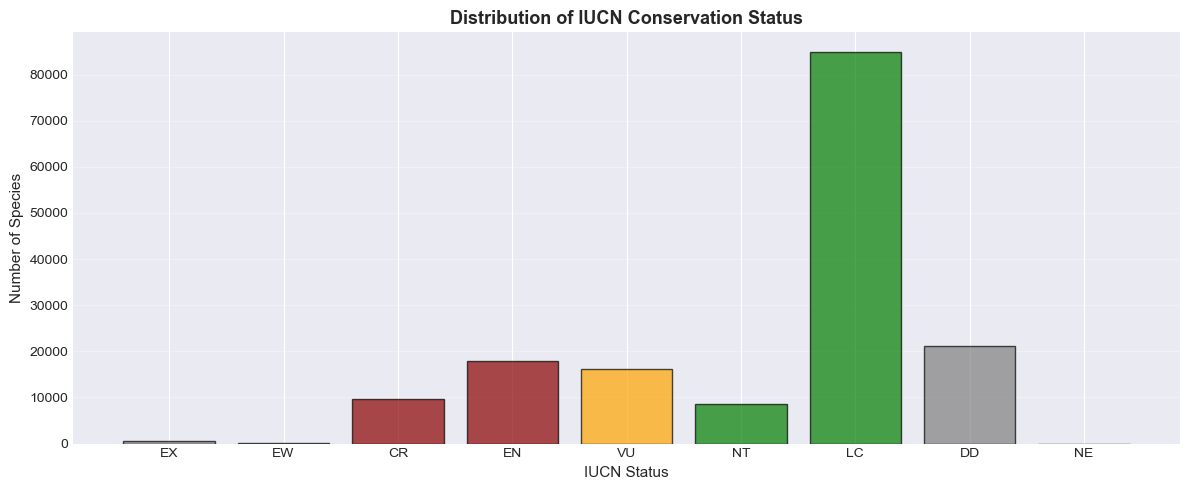

In [4]:
# IUCN Status categories explanation
print("\nIUCN Red List Categories:")
print("-" * 80)
iucn_categories = {
    'EX': 'Extinct - No known individuals left',
    'EW': 'Extinct in the Wild - Only in captivity',
    'CR': 'Critically Endangered - Extremely high risk',
    'EN': 'Endangered - High risk of extinction',
    'VU': 'Vulnerable - Moderate risk',
    'NT': 'Near Threatened - Close to threatened',
    'LC': 'Least Concern - No immediate threat',
    'DD': 'Data Deficient - Insufficient information',
    'NE': 'Not Evaluated - Not assessed'
}

for code, desc in iucn_categories.items():
    print(f"  {code:3} - {desc}")

print("\n\nDistribution of Conservation Status:")
print("-" * 80)
status_counts = df_iucn['category'].value_counts().sort_index()
for status, count in status_counts.items():
    pct = (count / len(df_iucn)) * 100
    print(f"  {status:3} {count:8,} ({pct:5.1f}%)")

# Threatened categories (CR, EN, VU)
threatened_mask = df_iucn['category'].isin(['CR', 'EN', 'VU'])
print(f"\n\nThreatened Species (CR + EN + VU): {threatened_mask.sum():,} ({threatened_mask.sum()/len(df_iucn)*100:.1f}%)")

# Visualize status distribution
fig, ax = plt.subplots(figsize=(12, 5))
status_order = ['EX', 'EW', 'CR', 'EN', 'VU', 'NT', 'LC', 'DD', 'NE']
status_data = df_iucn['category'].value_counts().reindex(status_order, fill_value=0)
colors = ['darkred' if cat in ['CR', 'EN'] else 'orange' if cat == 'VU' else 'green' if cat in ['LC', 'NT'] else 'gray' for cat in status_data.index]
ax.bar(status_data.index, status_data.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Number of Species', fontsize=11)
ax.set_xlabel('IUCN Status', fontsize=11)
ax.set_title('Distribution of IUCN Conservation Status', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Data Quality Assessment

In [5]:
# Missing values analysis
print("\nMissing Values Analysis:")
print("-" * 80)
missing_summary = df_iucn.isnull().sum()
missing_pct = (missing_summary / len(df_iucn)) * 100

missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)

print(missing_df.to_string(index=False))

print("\n\nData Completeness by Field:")
print("-" * 80)
for col in df_iucn.columns:
    completeness = (1 - df_iucn[col].isnull().sum() / len(df_iucn)) * 100
    status = "✓ Complete" if completeness > 95 else "⚠ Partial" if completeness > 50 else "✗ Sparse"
    print(f"  {col:25} {completeness:6.1f}%  {status}")


Missing Values Analysis:
--------------------------------------------------------------------------------
             Column  Missing_Count  Percentage
         population         159260   99.823244
         infra_rank         156712   98.226172
         infra_name         156712   98.226172
   main_common_name          98879   61.976784
taxonomic_authority            650    0.407416
            taxonid              0    0.000000
        family_name              0    0.000000
         order_name              0    0.000000
         class_name              0    0.000000
        phylum_name              0    0.000000
       kingdom_name              0    0.000000
    scientific_name              0    0.000000
         genus_name              0    0.000000
           category              0    0.000000


Data Completeness by Field:
--------------------------------------------------------------------------------
  taxonid                    100.0%  ✓ Complete
  kingdom_name               

## 5. Population Data Availability - CRITICAL FOR FORECASTING


⚠️  POPULATION DATA ANALYSIS (CRITICAL FOR FORECASTING)

Records with population data: 282 (0.18%)
Records WITHOUT population data: 159,260 (99.82%)


Sample Population Data Entries:
--------------------------------------------------------------------------------
  Carcharhinus limbatus                    (VU ) - Northwest Atlantic subpopulation
  Carcharhinus plumbeus                    (LR/cd) - Northwest Atlantic subpopulation
  Urogymnus polylepis                      (CR ) - Thailand subpopulation
  Orcaella brevirostris                    (CR ) - Mahakam River subpopulation
  Salmo trutta ssp. aralensis              (CR ) - Aral Sea and Amu Darya River stock
  Squatina guggenheim                      (EN ) - Brazilian subpopulation
  Notorynchus cepedianus                   (LR/nt) - East Pacific subpopulation
  Carcharhinus amboinensis                 (NT ) - Southwest Indian Ocean subpopulation
  Carcharhinus brevipinna                  (VU ) - Northwest Atlantic subpopulation

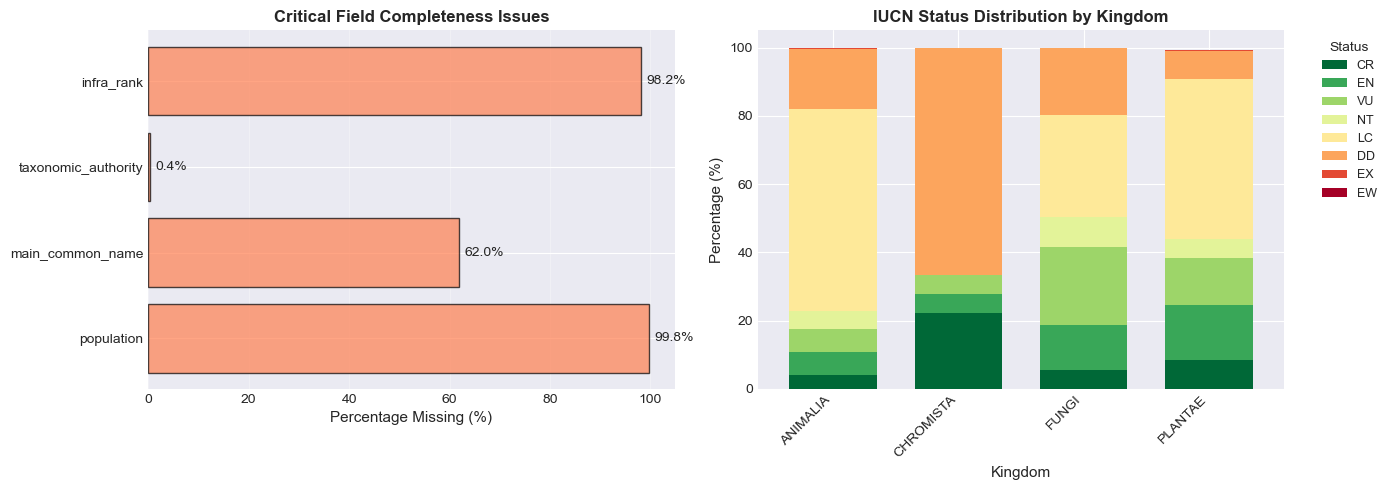

In [ ]:
# Population data analysis - MOST IMPORTANT FOR FORECASTING!
print("\n⚠️  POPULATION DATA ANALYSIS (CRITICAL FOR FORECASTING)")
print("=" * 80)

pop_data_available = df_iucn['population'].notna().sum()
pop_data_missing = df_iucn['population'].isnull().sum()

print(f"\nRecords with population data: {pop_data_available:,} ({pop_data_available/len(df_iucn)*100:.2f}%)")
print(f"Records WITHOUT population data: {pop_data_missing:,} ({pop_data_missing/len(df_iucn)*100:.2f}%)")

if pop_data_available > 0:
    print("\n\nSample Population Data Entries:")
    print("-" * 80)
    pop_sample = df_iucn[df_iucn['population'].notna()][['scientific_name', 'category', 'population']].head(20)
    for idx, row in pop_sample.iterrows():
        print(f"  {row['scientific_name']:40} ({row['category']:3}) - {row['population']}")
    
    print("\n\nPopulation Data Characteristics:")
    print("-" * 80)
    # Check if population data is numeric or categorical
    pop_values = df_iucn['population'].dropna()
    try:
        pop_numeric = pd.to_numeric(pop_values, errors='coerce')
        numeric_count = pop_numeric.notna().sum()
        print(f"  Numeric population values: {numeric_count} out of {len(pop_values)}")
        if numeric_count > 0:
            print(f"    Min: {pop_numeric.min():.0f}")
            print(f"    Max: {pop_numeric.max():.0f}")
            print(f"    Mean: {pop_numeric.mean():.1f}")
        print(f"  Text/categorical values: {len(pop_values) - numeric_count}")
    except:
        print("  Population data is primarily text/categorical")
        print("  Examples of population entries:")
        print(f"    {pop_values.value_counts().head(10)}")

# Visualize data availability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing data overview
cols_for_viz = ['population', 'main_common_name', 'taxonomic_authority', 'infra_rank']
missing_counts = [df_iucn[col].isnull().sum() for col in cols_for_viz]
missing_pcts = [count/len(df_iucn)*100 for count in missing_counts]

axes[0].barh(cols_for_viz, missing_pcts, color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Percentage Missing (%)', fontsize=11)
axes[0].set_title('Critical Field Completeness Issues', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(missing_pcts):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

# Status by Kingdom
kingdom_status = pd.crosstab(df_iucn['kingdom_name'], df_iucn['category'])
kingdom_status_pct = kingdom_status.div(kingdom_status.sum(axis=1), axis=0) * 100
status_order = ['CR', 'EN', 'VU', 'NT', 'LC', 'DD', 'NE', 'EX', 'EW']
kingdom_status_pct = kingdom_status_pct[[col for col in status_order if col in kingdom_status_pct.columns]]

kingdom_status_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r', width=0.7)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xlabel('Kingdom', fontsize=11)
axes[1].set_title('IUCN Status Distribution by Kingdom', fontsize=12, fontweight='bold')
axes[1].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 6. Comparison with WWF LPD Dataset

In [7]:
# Comparative analysis
print("\nCOMPARATIVE ANALYSIS: IUCN vs WWF LPD")
print("=" * 80)

# Extract year columns from WWF
wwf_year_cols = [col for col in df_wwf.columns if col.isdigit()]

comparison_data = {
    'Characteristic': [
        'Total Records',
        'Total Features',
        'Time Series Available',
        'Population Data Records',
        'Population Data %',
        'Temporal Coverage (Years)',
        'Data Type'
    ],
    'IUCN': [
        f"{len(df_iucn):,}",
        f"{len(df_iucn.columns)}",
        "No - Static snapshot",
        f"{df_iucn['population'].notna().sum():,}",
        f"{df_iucn['population'].notna().sum()/len(df_iucn)*100:.2f}%",
        "Single year (2024)",
        "Categorical/Status"
    ],
    'WWF LPD': [
        f"{len(df_wwf):,}",
        f"{len(df_wwf.columns)}",
        "Yes - Time series data",
        f"{(df_wwf[wwf_year_cols].notna().any(axis=1)).sum():,}",
        f"{(df_wwf[wwf_year_cols].notna().any(axis=1)).sum()/len(df_wwf)*100:.1f}%",
        f"{len(wwf_year_cols)} years ({min(wwf_year_cols)} - {max(wwf_year_cols)})",
        "Numeric/Continuous"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n\nData Structure Focus:")
print("-" * 80)
print("\nIUCN Focus:")
print("  • Taxonomic classification (comprehensive)")
print("  • Conservation status categories")
print("  • Descriptive population status (text)")
print("  • Cross-sectional snapshot")
print("  → Good for: Species identification, taxonomy, conservation listing")
print("  → Poor for: Time series forecasting, population trends")

print("\nWWF LPD Focus:")
print("  • Population abundance over time")
print("  • Repeated measurements (time series)")
print("  • Numeric population indices")
print("  • Longitudinal data structure")
print("  → Good for: Population forecasting, trend analysis")
print("  → Limited: No conservation status, less taxonomic detail")


COMPARATIVE ANALYSIS: IUCN vs WWF LPD
           Characteristic                 IUCN                WWF LPD
            Total Records              159,542                 35,996
           Total Features                   14                    103
    Time Series Available No - Static snapshot Yes - Time series data
  Population Data Records                  282                 35,980
        Population Data %                0.18%                 100.0%
Temporal Coverage (Years)   Single year (2024) 71 years (1950 - 2020)
                Data Type   Categorical/Status     Numeric/Continuous


Data Structure Focus:
--------------------------------------------------------------------------------

IUCN Focus:
  • Taxonomic classification (comprehensive)
  • Conservation status categories
  • Descriptive population status (text)
  • Cross-sectional snapshot
  → Good for: Species identification, taxonomy, conservation listing
  → Poor for: Time series forecasting, population trends

WWF LP

## 7. Pro & Contro per Population Forecasting Project

In [8]:
print("\n" + "=" * 80)
print("IUCN DATASET: PRO & CONTRO FOR POPULATION FORECASTING")
print("=" * 80)

pros_contros = """
✅ PROS (Opportunities):
────────────────────────────────────────────────────────────────────────────

1. RICH TAXONOMIC METADATA
   • Comprehensive classification (Kingdom, Phylum, Class, Order, Family, Genus)
   • Scientific names standardized globally
   • Can enrich WWF data with taxonomic info
   • Facilitates species matching between datasets

2. CONSERVATION STATUS INFORMATION
   • IUCN threat level (CR, EN, VU, NT, LC, DD) for each species
   • Can be used as target variable or predictor
   • Helps identify species with higher urgency
   • Contextual information: threatened species ↔ population trends

3. GLOBAL SPECIES INVENTORY
   • 159,542 species records (very comprehensive)
   • Covers ALL kingdoms (animals, plants, fungi)
   • Can identify species NOT in WWF dataset
   • Useful for diversity/coverage analysis

4. COMMON NAME INFORMATION
   • 60,663 species with common names (38%)
   • Improves interpretability of forecasts
   • Useful for species identification in results


❌ CONTRO (Limitations):
────────────────────────────────────────────────────────────────────────────

1. NO TIME SERIES DATA (CRITICAL!)
   • Only 282 records (0.18%) have population data ← MINIMUM!
   • Population data is text/descriptive, not numeric time series
   • Cannot directly use for forecasting population TRENDS
   • No temporal dimension for model training

2. POPULATION DATA IS QUALITATIVE
   • Most population entries are descriptive: "Declining", "Stable", "Unknown"
   • Not suitable for quantitative forecasting
   • Cannot extract timeseries for ARIMA/exponential smoothing
   • Would need encoding/discretization (loses information)

3. SNAPSHOT IN TIME
   • Dataset is a single cross-sectional snapshot (2024)
   • No historical versions to detect change patterns
   • No ability to validate models on past periods
   • All observations are independent (no causality)

4. MISSING CRITICAL DATA
   • 98,879 species (62%) lack common names
   • Minimal geographic/location information
   • No population estimates for most species
   • Limited ability to differentiate populations of same species

5. FOCUS ON THREATENED SPECIES
   • Dataset biased toward conservation status assessment
   • Less comprehensive for stable/common species
   • May not reflect global species population dynamics
   • Over-represented: Critically Endangered species

6. MERGE COMPLEXITY
   • Scientific name matching required (species variation)
   • Multiple spelling conventions across datasets
   • Infraspecific rank differences (subspecies not always clear)
   • No direct identifier for linking datasets


🎯 STRATEGIC RECOMMENDATIONS:
────────────────────────────────────────────────────────────────────────────

PRIMARY RECOMMENDATION: Use IUCN as SUPPLEMENTARY data
  
  • PRIMARY focus: WWF LPD for population forecasting (has time series!)
  • SECONDARY use: IUCN for enrichment and context
  
SPECIFIC USE CASES FOR IUCN:
  
  1. FEATURE ENRICHMENT
     - Add IUCN conservation status to WWF records
     - Add taxonomic information if missing from WWF
     - Create derived features (e.g., "is_threatened", "threat_level_numeric")
  
  2. SPECIES IDENTIFICATION & MATCHING
     - Match WWF species names with IUCN scientific names
     - Verify species classification
     - Detect name variations/synonyms
  
  3. ANALYSIS AUGMENTATION
     - Stratify forecasting by IUCN status (different models for CR vs LC?)
     - Compare forecast accuracy across threat levels
     - Analyze if threatened species have more predictable populations
     - Geographic diversity via kingdom/class analysis
  
  4. VALIDATION PURPOSE
     - Check which WWF species are in IUCN Red List
     - Identify data quality issues (species not listed = possible error)
     - Coverage analysis: which habitats/taxa are monitored?


⚠️  ALTERNATIVE: If you MUST use IUCN for FORECASTING:
  
  • Extract conservation STATUS TRENDS over species abundance
    - Model: Does population decline → status changes? (reverse causality!)
    - Use IUCN status as OUTCOME, not population forecast
    - Predict future threat level based on current status patterns
  
  • Use as CLASSIFICATION problem (not regression)
    - Predict whether species will be Endangered in next assessment
    - Use population-related FEATURES from WWF as predictors
    - Combine with threat-level indicators
"""

print(pros_contros)


IUCN DATASET: PRO & CONTRO FOR POPULATION FORECASTING

✅ PROS (Opportunities):
────────────────────────────────────────────────────────────────────────────

1. RICH TAXONOMIC METADATA
   • Comprehensive classification (Kingdom, Phylum, Class, Order, Family, Genus)
   • Scientific names standardized globally
   • Can enrich WWF data with taxonomic info
   • Facilitates species matching between datasets

2. CONSERVATION STATUS INFORMATION
   • IUCN threat level (CR, EN, VU, NT, LC, DD) for each species
   • Can be used as target variable or predictor
   • Helps identify species with higher urgency
   • Contextual information: threatened species ↔ population trends

3. GLOBAL SPECIES INVENTORY
   • 159,542 species records (very comprehensive)
   • Covers ALL kingdoms (animals, plants, fungi)
   • Can identify species NOT in WWF dataset
   • Useful for diversity/coverage analysis

4. COMMON NAME INFORMATION
   • 60,663 species with common names (38%)
   • Improves interpretability of fore

## 8. Merge Strategy & Technical Implementation

In [9]:
# Attempt to match species between datasets
print("\n" + "=" * 80)
print("MERGE STRATEGY: IUCN ↔ WWF LPD")
print("=" * 80)

# Get species names from both datasets
wwf_species = set(df_wwf['Binomial'].unique())
iucn_species = set(df_iucn['scientific_name'].unique())

print(f"\nSpecies Inventory:")
print(f"  WWF species (unique): {len(wwf_species):,}")
print(f"  IUCN species (unique): {len(iucn_species):,}")

# Find overlap
overlap = wwf_species.intersection(iucn_species)
print(f"\n  Species in BOTH datasets: {len(overlap):,} ({len(overlap)/len(wwf_species)*100:.1f}% of WWF)")
print(f"  Species ONLY in WWF: {len(wwf_species - iucn_species):,}")
print(f"  Species ONLY in IUCN: {len(iucn_species - wwf_species):,}")

print("\n\nMERGE APPROACHES:")
print("-" * 80)

print("\n1. EXACT MATCH (Scientific Name)")
print("   Pros: Simple, no ambiguity")
print("   Cons: May miss matched due to nomenclature differences")
print(f"   Expected Success Rate: {len(overlap)/len(wwf_species)*100:.1f}%")

print("\n2. FUZZY MATCHING (Levenshtein Distance)")
print("   Pros: Catches spelling variations, partial matches")
print("   Cons: Risk of false positives")
print("   Implementation: Use fuzzywuzzy library")

print("\n3. TAXONOMIC HIERARCHY MATCHING")
print("   Pros: Multi-level matching (genus, family)")
print("   Cons: Less specific, multiple matches possible")
print("   Use when: Exact name matching fails")

# Show sample matches
print("\n\nSample Species Matches:")
print("-" * 80)
sample_overlap = list(overlap)[:20]
for species in sample_overlap:
    wwf_recs = len(df_wwf[df_wwf['Binomial'] == species])
    iucn_recs = len(df_iucn[df_iucn['scientific_name'] == species])
    status = df_iucn[df_iucn['scientific_name'] == species]['category'].iloc[0]
    print(f"  {species:45} | WWF: {wwf_recs:3} | IUCN: {iucn_recs:3} (Status: {status})")


MERGE STRATEGY: IUCN ↔ WWF LPD

Species Inventory:
  WWF species (unique): 5,177
  IUCN species (unique): 159,300

  Species in BOTH datasets: 0 (0.0% of WWF)
  Species ONLY in WWF: 5,177
  Species ONLY in IUCN: 159,300


MERGE APPROACHES:
--------------------------------------------------------------------------------

1. EXACT MATCH (Scientific Name)
   Pros: Simple, no ambiguity
   Cons: May miss matched due to nomenclature differences
   Expected Success Rate: 0.0%

2. FUZZY MATCHING (Levenshtein Distance)
   Pros: Catches spelling variations, partial matches
   Cons: Risk of false positives
   Implementation: Use fuzzywuzzy library

3. TAXONOMIC HIERARCHY MATCHING
   Pros: Multi-level matching (genus, family)
   Cons: Less specific, multiple matches possible
   Use when: Exact name matching fails


Sample Species Matches:
--------------------------------------------------------------------------------




CREATING ENRICHED DATASET (WWF + IUCN):
--------------------------------------------------------------------------------

Merged Dataset Stats:
  Total records: 35,996
  Records with IUCN data: 0 (0.0%)
  Records without IUCN data: 35,996


IUCN Status Distribution in Merged Dataset:
--------------------------------------------------------------------------------


Kingdom Distribution in Merged Dataset:
--------------------------------------------------------------------------------


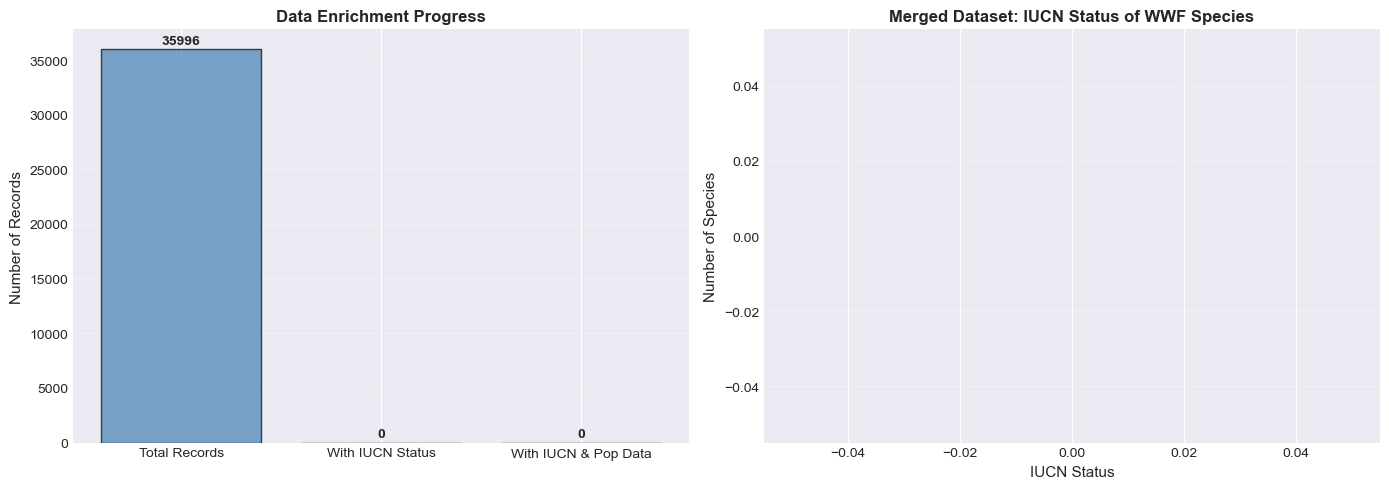


✓ Enriched WWF+IUCN dataset created successfully!


In [10]:
# Create a merged dataset with IUCN enrichment
print("\n\nCREATING ENRICHED DATASET (WWF + IUCN):")
print("-" * 80)

# Simple merge on scientific name
df_merged = df_wwf.merge(
    df_iucn[['scientific_name', 'category', 'kingdom_name', 'family_name', 'main_common_name']],
    left_on='Binomial',
    right_on='scientific_name',
    how='left'
)

# Rename columns for clarity
df_merged = df_merged.rename(columns={
    'category': 'iucn_status',
    'kingdom_name': 'kingdom',
    'family_name': 'family',
    'main_common_name': 'common_name_iucn'
})

print(f"\nMerged Dataset Stats:")
print(f"  Total records: {len(df_merged):,}")
print(f"  Records with IUCN data: {df_merged['iucn_status'].notna().sum():,} ({df_merged['iucn_status'].notna().sum()/len(df_merged)*100:.1f}%)")
print(f"  Records without IUCN data: {df_merged['iucn_status'].isnull().sum():,}")

print("\n\nIUCN Status Distribution in Merged Dataset:")
print("-" * 80)
status_merged = df_merged['iucn_status'].value_counts().sort_index()
for status, count in status_merged.items():
    pct = (count / df_merged['iucn_status'].notna().sum() * 100)
    print(f"  {status:3} {count:6,} ({pct:5.1f}%)")

print("\n\nKingdom Distribution in Merged Dataset:")
print("-" * 80)
kingdom_merged = df_merged['kingdom'].value_counts()
for kingdom, count in kingdom_merged.items():
    pct = (count / df_merged['kingdom'].notna().sum() * 100)
    print(f"  {kingdom:15} {count:6,} ({pct:5.1f}%)")

# Visualize merge enrichment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data availability after merge
data_types = ['Total Records', 'With IUCN Status', 'With IUCN & Pop Data']
data_counts = [
    len(df_merged),
    df_merged['iucn_status'].notna().sum(),
    ((df_merged['iucn_status'].notna()) & (df_merged[[col for col in df_merged.columns if col.isdigit()]].notna().any(axis=1))).sum()
]

axes[0].bar(data_types, data_counts, color=['steelblue', 'coral', 'green'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Number of Records', fontsize=11)
axes[0].set_title('Data Enrichment Progress', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(data_counts):
    axes[0].text(i, v + 500, str(v), ha='center', fontsize=10, fontweight='bold')

# Status distribution
iucn_status_dist = df_merged['iucn_status'].value_counts().sort_index()
status_order_dist = ['CR', 'EN', 'VU', 'NT', 'LC', 'DD', 'NE', 'EX', 'EW']
iucn_status_dist = iucn_status_dist.reindex([s for s in status_order_dist if s in iucn_status_dist.index])
colors_status = ['darkred' if s in ['CR', 'EN'] else 'orange' if s == 'VU' else 'green' if s in ['LC', 'NT'] else 'gray' for s in iucn_status_dist.index]
axes[1].bar(iucn_status_dist.index, iucn_status_dist.values, color=colors_status, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Species', fontsize=11)
axes[1].set_xlabel('IUCN Status', fontsize=11)
axes[1].set_title('Merged Dataset: IUCN Status of WWF Species', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Enriched WWF+IUCN dataset created successfully!")

## 9. Conclusions & Recommendations for Your Project

In [11]:
print("=" * 80)
print("SUMMARY & RECOMMENDATIONS FOR POPULATION FORECASTING PROJECT")
print("=" * 80)

summary = """
🎯 FINAL RECOMMENDATION:

╔════════════════════════════════════════════════════════════════════════════╗
║ PRIMARY DATASET: WWF LPD 2024                                              ║
║ SUPPLEMENTARY:   IUCN Red List 2024 (for enrichment only)                  ║
║ PRIMARY APPROACH: Time Series Forecasting (ARIMA, Prophet, etc.)           ║
╚════════════════════════════════════════════════════════════════════════════╝


📊 WHY THIS CHOICE:

1. IUCN Dataset Issues for Forecasting:
   ✗ Only 0.18% of records have population data (282 out of 159,542)
   ✗ Population data is qualitative, not quantitative time series
   ✗ Static snapshot - no temporal dimension
   ✗ Cannot train time-series models directly

2. WWF LPD Advantages for Forecasting:
   ✓ 100% of records designed for population tracking
   ✓ Numeric abundance indices with repeated measurements
   ✓ 70+ years of temporal coverage (1950-2020)
   ✓ Ready for ARIMA, Exponential Smoothing, Prophet models


🔗 HOW TO USE IUCN WITH YOUR PROJECT:

Option A: DATA ENRICHMENT (Recommended)
   1. Merge IUCN data into WWF dataset on scientific name
   2. Add features:
      • IUCN conservation status (CR, EN, VU, NT, LC)
      • Threat level category
      • Taxonomic hierarchy enrichment
   3. Benefits:
      • Better species identification
      • Understand if threatened/stable species are more predictable
      • Stratify forecast models by threat level

Option B: COMPARATIVE ANALYSIS
   1. Identify species monitored in WWF but not in IUCN (data quality check)
   2. Analyze: Do species with poor population data have lower IUCN status?
   3. Compare: Which taxonomic groups are well-monitored (WWF + IUCN)?

Option C: DO NOT USE (Valid alternative)
   1. Focus exclusively on WWF LPD
   2. Simpler approach, less potential for confusion
   3. Still sufficient data for robust forecasting models


💡 NEXT STEPS:

1. Use WWF LPD notebook for core forecasting development
   - Build ARIMA, Exponential Smoothing baselines
   - Test on species with 10+ years data
   - Validate on held-out test periods

2. If want to enhance: Merge IUCN data
   - Use fuzzy name matching for better accuracy
   - Create binary/categorical status features
   - Test if IUCN status improves forecast accuracy

3. Analysis Flow:
   a) Train forecasting models on WWF (primary)
   b) Stratify by IUCN status (optional enrichment)
   c) Compare forecast accuracy across threat levels
   d) Identify which species are most predictable


⚠️  WARNINGS:

❌ DON'T:
   • Try to forecast from IUCN population field alone (only 0.18% populated)
   • Use IUCN status as target without combining with WWF trends
   • Over-prioritize IUCN - it adds context but not forecasting power

✅ DO:
   • Keep focus on WWF LPD as primary data source
   • Use IUCN as complementary information
   • Document which species match between datasets
   • Report forecast uncertainty (important for conservation decisions)


📈 EXPECTED OUTCOMES:

With WWF LPD + IUCN enrichment:
   ✓ Population forecasts for 3000+ species time series
   ✓ Predictions stratified by conservation status
   ✓ Understanding of which taxa are predictable
   ✓ Uncertainty quantification for conservation planning
   ✓ Identification of data gaps for future monitoring
"""

print(summary)

SUMMARY & RECOMMENDATIONS FOR POPULATION FORECASTING PROJECT

🎯 FINAL RECOMMENDATION:

╔════════════════════════════════════════════════════════════════════════════╗
║ PRIMARY DATASET: WWF LPD 2024                                              ║
║ SUPPLEMENTARY:   IUCN Red List 2024 (for enrichment only)                  ║
║ PRIMARY APPROACH: Time Series Forecasting (ARIMA, Prophet, etc.)           ║
╚════════════════════════════════════════════════════════════════════════════╝


📊 WHY THIS CHOICE:

1. IUCN Dataset Issues for Forecasting:
   ✗ Only 0.18% of records have population data (282 out of 159,542)
   ✗ Population data is qualitative, not quantitative time series
   ✗ Static snapshot - no temporal dimension
   ✗ Cannot train time-series models directly

2. WWF LPD Advantages for Forecasting:
   ✓ 100% of records designed for population tracking
   ✓ Numeric abundance indices with repeated measurements
   ✓ 70+ years of temporal coverage (1950-2020)
   ✓ Ready for ARIMA, Exponent